```markdown
# Semana 1 - Día 3: Redes Multicapa, Validación y Problemas Multiclase
**Especialización en Ciencia de Datos e Inteligencia Artificial - UdeMedellín**

Hasta ahora hemos trabajado con problemas de "juguete" de dos variables. Hoy daremos el salto a la realidad del Científico de Datos: **Múltiples variables (Multivariado), evaluación rigurosa y predicción de múltiples categorías (Multiclase)**.

## PARTE 1: El Problema Multivariado (Predicción de Fuga de Clientes)
Imagina que trabajamos en una empresa de telecomunicaciones (como Celsia o Tigo). Queremos predecir si un cliente va a cancelar su servicio (**Fuga / Churn = 1**) o si se va a quedar (**Retención = 0**).

Esta vez, no usaremos solo 2 variables, sino 5 características del cliente:
1. Meses con la empresa (Antigüedad).
2. Costo del plan mensual.
3. Cantidad de llamadas a servicio al cliente (Quejas).
4. Retrasos en el pago.
5. Consumo de gigas de internet.

```

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# 1. GENERACIÓN DE DATOS (5 variables, 2000 clientes)
# Usamos una herramienta de scikit-learn para crear un dataset realista rápidamente
X, y = make_classification(
    n_samples=2000,
    n_features=5,       # Nuestras 5 variables de negocio
    n_informative=4,    # 4 variables son útiles para predecir
    n_redundant=1,      # 1 variable es "ruido" o está repetida
    random_state=42
)

print(f"Formato de los datos (X): {X.shape} -> 2000 clientes, 5 variables cada uno.")
print(f"Formato de las etiquetas (y): {y.shape} -> 2000 respuestas (0 o 1).")

Formato de los datos (X): (2000, 5) -> 2000 clientes, 5 variables cada uno.
Formato de las etiquetas (y): (2000,) -> 2000 respuestas (0 o 1).


```markdown
## 2. La Regla de Oro: Entrenamiento, Validación y Prueba
El peor error en Machine Learning es evaluar un modelo con los mismos datos que usó para aprender (es como darle a un estudiante el examen resuelto antes de la prueba).

Para saber si nuestro modelo realmente "entiende" los patrones y no solo "memoriza", dividimos los datos en tres grupos:
* **Entrenamiento (Train - 70%):** Los datos que el modelo usa para aprender (calcular el gradiente y ajustar pesos).
* **Validación (Validation - 15%):** Datos que el modelo *no usa para aprender*, pero que usamos al final de cada época para ver cómo va progresando y detectar si está memorizando de más (Overfitting).
* **Prueba (Test - 15%):** Datos completamente nuevos y aislados. Se usan una sola vez al final del proyecto para simular el desempeño en la vida real.

```

In [ ]:
# 2. SEPARACIÓN DE LOS DATOS

# Primero, sacamos el 70% para Entrenamiento y dejamos un 30% temporal
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)

# Ahora, dividimos ese 30% temporal a la mitad: 15% para Validación y 15% para Prueba
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f"Clientes para Entrenar (Train): {len(X_train)}")
print(f"Clientes para Validar (Validation): {len(X_val)}")
print(f"Clientes para Probar (Test Final): {len(X_test)}")

Clientes para Entrenar (Train): 1400
Clientes para Validar (Validation): 300
Clientes para Probar (Test Final): 300


```markdown
## 3. Construcción y Entrenamiento del Modelo Multicapa
Vamos a crear una red más profunda. Como tenemos 5 entradas de datos, la primera capa oculta debe ser capaz de procesar esa complejidad.

```

In [ ]:
# Construimos la arquitectura de la red
modelo_fuga = Sequential()

# Primera capa oculta (Input_dim ahora es 5)
modelo_fuga.add(Dense(units=8, input_dim=5, activation='relu'))

# Primera capa oculta (Input_dim ahora es 5)
modelo_fuga.add(Dense(units=4, activation='relu'))

# Capa de salida (1 neurona, activación sigmoide porque es un problema binario 0 o 1)
modelo_fuga.add(Dense(units=1, activation='sigmoid'))

# Compilamos añadiendo métricas extra (Precision y Recall además del Accuracy)
modelo_fuga.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
)

modelo_fuga.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 8)              │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89 (356.00 B)

 Trainable params: 89 (356.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:

# Entrenamos incluyendo los datos de validación
print("Iniciando entrenamiento...")
historial = modelo_fuga.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32, # Toma grupos de 32 clientes antes de actualizar los pesos
    validation_data=(X_val, y_val), # Keras evaluará el modelo en estos datos al final de cada época
    verbose=1
)
print("¡Entrenamiento finalizado!")

Iniciando entrenamiento...
Epoch 1/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.5837 - loss: 0.6794 - precision: 0.6142 - recall: 0.5482 - val_accuracy: 0.7433 - val_loss: 0.6613 - val_precision: 0.8115 - val_recall: 0.6471
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7224 - loss: 0.6527 - precision: 0.8192 - recall: 0.5621 - val_accuracy: 0.7567 - val_loss: 0.6193 - val_precision: 0.8922 - val_recall: 0.5948
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7532 - loss: 0.6147 - precision: 0.8795 - recall: 0.5560 - val_accuracy: 0.7700 - val_loss: 0.5883 - val_precision: 0.8621 - val_recall: 0.6536
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7520 - loss: 0.5856 - precision: 0.8465 - recall: 0.6310 - val_accuracy: 0.7933 - val_loss: 0.5378 - val_precision: 0.8421 - val_recall: 0.7320
Epoch 5/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7866 - loss: 0.5186 - precision: 0.8401 - recall: 0.7037 - val_accuracy

```markdown
## 4. Análisis de Curvas de Aprendizaje (Train vs Validation)
Aquí es donde el analista de datos brilla. Comparar el desempeño en el grupo de Entrenamiento vs. el de Validación nos dice si el modelo va por buen camino.
* Si Train mejora pero Validation empeora, el modelo está **sobreajustando (Overfitting)**.

```

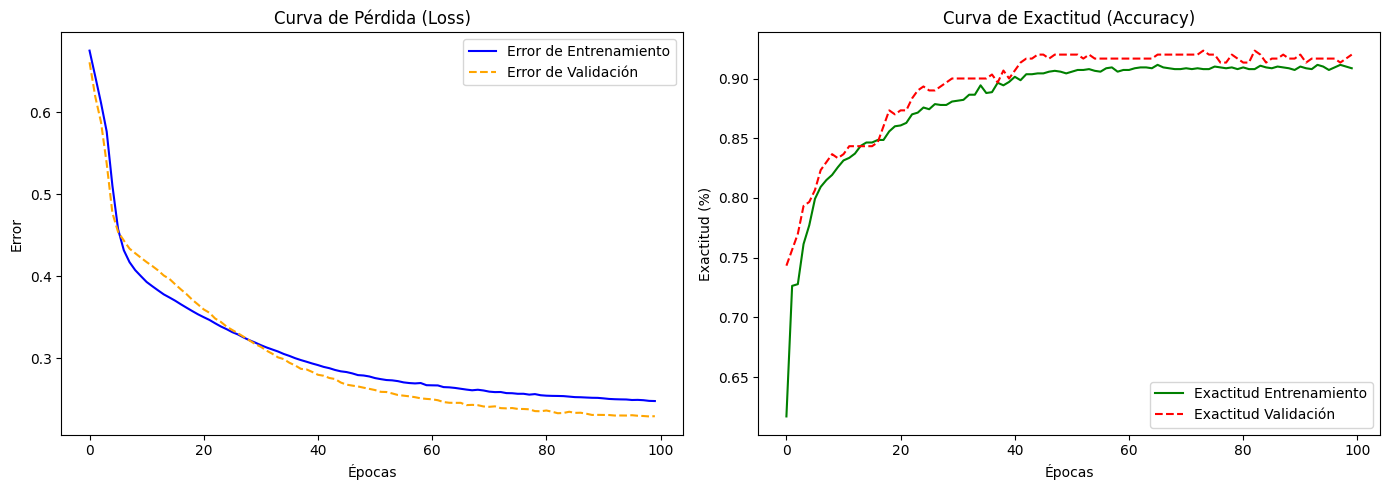

In [ ]:
# Graficamos la Pérdida (Error)
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(historial.history['loss'], label='Error de Entrenamiento', color='blue')
plt.plot(historial.history['val_loss'], label='Error de Validación', color='orange', linestyle='--')
plt.title('Curva de Pérdida (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Error')
plt.legend()

# Graficamos la Exactitud (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(historial.history['accuracy'], label='Exactitud Entrenamiento', color='green')
plt.plot(historial.history['val_accuracy'], label='Exactitud Validación', color='red', linestyle='--')
plt.title('Curva de Exactitud (Accuracy)')
plt.xlabel('Épocas')
plt.ylabel('Exactitud (%)')
plt.legend()

plt.tight_layout()
plt.show()

```markdown
## 5. Evaluación Final con Datos de Prueba y Múltiples Métricas
La prueba de fuego. Usamos el set de Test (15% que guardamos al principio) para ver cómo operaría el modelo hoy en producción.
En negocios, el Accuracy no es suficiente. Por eso usamos la **Matriz de Confusión**.

```

Desempeño en Vida Real (Test) -> Loss: 0.2977 | Accuracy: 87.67%
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


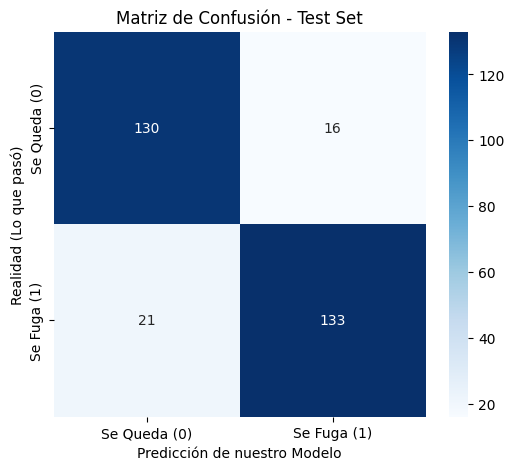


Reporte de Clasificación Detallado:
              precision    recall  f1-score   support

    Se Queda       0.86      0.89      0.88       146
     Se Fuga       0.89      0.86      0.88       154

    accuracy                           0.88       300
   macro avg       0.88      0.88      0.88       300
weighted avg       0.88      0.88      0.88       300



In [ ]:
# Evaluamos en el set de prueba
resultados = modelo_fuga.evaluate(X_test, y_test, verbose=0)
print(f"Desempeño en Vida Real (Test) -> Loss: {resultados[0]:.4f} | Accuracy: {resultados[1]*100:.2f}%")

# Hacemos las predicciones (Nos da probabilidades, así que redondeamos a 0 o 1)
predicciones_prob = modelo_fuga.predict(X_test)
predicciones_clase = np.round(predicciones_prob).flatten()

# Matriz de Confusión
matriz = confusion_matrix(y_test, predicciones_clase)

# Visualización bonita de la matriz para los administradores
plt.figure(figsize=(6,5))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Se Queda (0)', 'Se Fuga (1)'],
            yticklabels=['Se Queda (0)', 'Se Fuga (1)'])
plt.ylabel('Realidad (Lo que pasó)')
plt.xlabel('Predicción de nuestro Modelo')
plt.title('Matriz de Confusión - Test Set')
plt.show()

# Reporte detallado
print("\nReporte de Clasificación Detallado:")
print(classification_report(y_test, predicciones_clase, target_names=['Se Queda', 'Se Fuga']))

---

```markdown
## PARTE 2: Clasificación Multiclase (Más de 2 opciones)
¿Qué pasa si el problema no es un sí/no? Imagina que en lugar de fuga, queremos hacer **Segmentación de Clientes** en 3 categorías:
* **Clase 0:** Cliente Básico (Plan económico)
* **Clase 1:** Cliente Estándar (Plan regular)
* **Clase 2:** Cliente VIP (Plan premium)

La estructura de la red cambia ligeramente en su capa de salida:
1. Necesitamos **tantas neuronas de salida como clases tengamos** (3 en este caso).
2. Cambiamos la activación final a **`softmax`**. Softmax toma las salidas y las convierte en porcentajes que suman el 100%. (Ej. 10% Básico, 20% Estándar, 70% VIP -> Gana VIP).
3. Cambiamos la función de pérdida a **`sparse_categorical_crossentropy`**.

```

In [ ]:
# 1. Generamos datos ficticios pero ahora con 3 clases
X_multi, y_multi = make_classification(
    n_samples=1500,
    n_features=6,
    n_informative=4,
    n_classes=3,     # ¡Tres categorías de clientes!
    random_state=10
)

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_multi, test_size=0.2, random_state=10)

# 2. Construimos el modelo Multiclase
modelo_segmentos = Sequential()
modelo_segmentos.add(Dense(16, input_dim=6, activation='relu'))
modelo_segmentos.add(Dense(8, activation='relu'))
modelo_segmentos.add(Dense(6, activation='relu'))

# CAMBIO CLAVE: 3 neuronas (para las 3 clases) y activación 'softmax'
modelo_segmentos.add(Dense(3, activation='softmax'))

# CAMBIO CLAVE: La función de pérdida (loss) cambia para problemas multiclase
modelo_segmentos.compile(optimizer='adam',
                         loss='sparse_categorical_crossentropy',
                         metrics=['accuracy'])

# 3. Entrenamos
print("\nEntrenando Modelo Multiclase...")
historial_multi = modelo_segmentos.fit(X_train_m, y_train_m, epochs=50, validation_split=0.2, verbose=0)
print("¡Entrenamiento finalizado!")



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Entrenando Modelo Multiclase...
¡Entrenamiento finalizado!


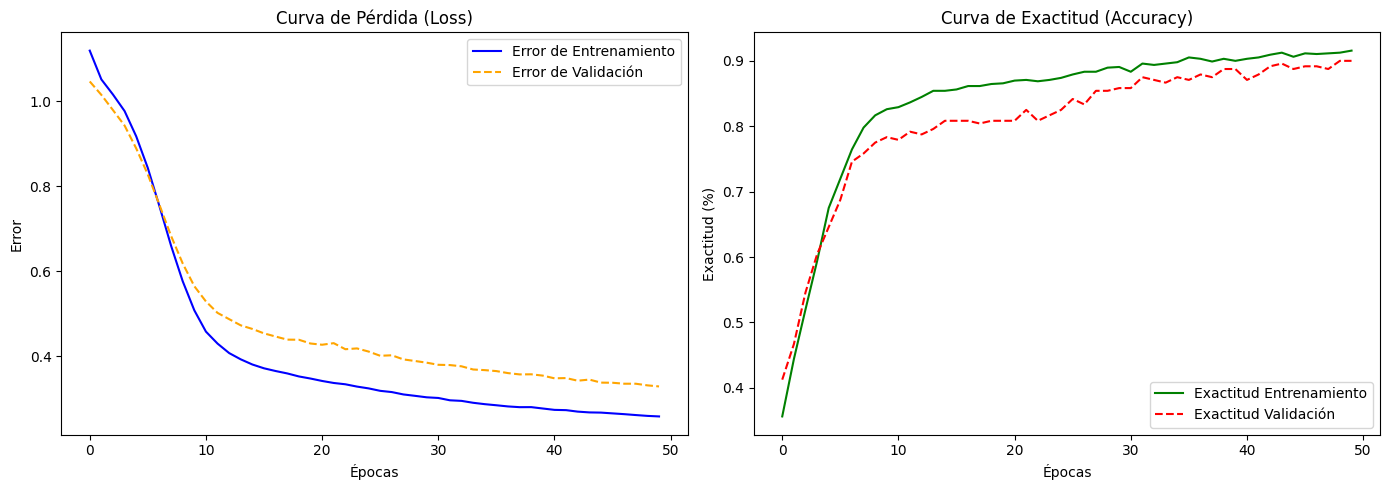

In [ ]:
# Graficamos la Pérdida (Error)
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(historial_multi.history['loss'], label='Error de Entrenamiento', color='blue')
plt.plot(historial_multi.history['val_loss'], label='Error de Validación', color='orange', linestyle='--')
plt.title('Curva de Pérdida (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Error')
plt.legend()

# Graficamos la Exactitud (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(historial_multi.history['accuracy'], label='Exactitud Entrenamiento', color='green')
plt.plot(historial_multi.history['val_accuracy'], label='Exactitud Validación', color='red', linestyle='--')
plt.title('Curva de Exactitud (Accuracy)')
plt.xlabel('Épocas')
plt.ylabel('Exactitud (%)')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# 4. Probamos con un cliente nuevo (el primer cliente del test set)
cliente_nuevo = X_test_m[1].reshape(1, -1)
probabilidades = modelo_segmentos.predict(cliente_nuevo)

print(f"\nProbabilidades asignadas por la red (Softmax):")
print(f"Básico: {probabilidades[0][0]*100:.2f}%")
print(f"Estándar: {probabilidades[0][1]*100:.2f}%")
print(f"VIP: {probabilidades[0][2]*100:.2f}%")

clase_ganadora = np.argmax(probabilidades) # Extrae la posición del porcentaje más alto
print(f"-> El modelo clasifica a este cliente en la Categoría: {clase_ganadora}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step

Probabilidades asignadas por la red (Softmax):
Básico: 5.59%
Estándar: 94.29%
VIP: 0.12%
-> El modelo clasifica a este cliente en la Categoría: 1
